# Training Checkpoints
This notebook contains code for training the model checkpoints used in various experiments

In [ ]:
# Install dependencies
!pip install -r requirements.txt

In [3]:
# Imports
import torch
from torch import nn
from torch.utils.data import DataLoader

import matplotlib
import matplotlib.pyplot as plt

from omegaconf import OmegaConf, DictConfig

# Basic utils for data, optimizer, and model handling
from utils import load_dataset, init_optimizer, init_model, save_checkpoint

# Import training script
from train import train

In [4]:
# Global definitions
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(f"Running on device: {device}")

# Set up plotting formatting settings
matplotlib.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.latex.preamble": r"\usepackage{amsmath}",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12,
})


Running on device: cuda:0


# CIFAR-100
First, we train some basic checkpoints for computing accuracy on CIFAR-100

In [3]:
# Load the datasets
train_set, val_set, _test_set = load_dataset("cifar100", train_ratio=0.9, seed=42)

train_loader = DataLoader(train_set, batch_size=50, shuffle=True)
val_loader = DataLoader(val_set, batch_size=50, shuffle=False)

### IVON

Epoch 0; train_loss=4.053; val_loss=3.72
Saving checkpoint to 'checkpoints/cifar100/resnet20__ivon__1.pt' ...
Epoch 1; train_loss=3.496; val_loss=3.229
Saving checkpoint to 'checkpoints/cifar100/resnet20__ivon__2.pt' ...
Epoch 2; train_loss=3.12; val_loss=2.933
Epoch 3; train_loss=2.826; val_loss=2.738
Epoch 4; train_loss=2.593; val_loss=2.599
Saving checkpoint to 'checkpoints/cifar100/resnet20__ivon__5.pt' ...
Epoch 5; train_loss=2.413; val_loss=2.438
Epoch 6; train_loss=2.24; val_loss=2.304
Epoch 7; train_loss=2.1; val_loss=2.191
Epoch 8; train_loss=1.993; val_loss=2.109
Epoch 9; train_loss=1.914; val_loss=2.097
Saving checkpoint to 'checkpoints/cifar100/resnet20__ivon__10.pt' ...
Epoch 10; train_loss=1.836; val_loss=2.071
Epoch 11; train_loss=1.778; val_loss=2.05
Epoch 12; train_loss=1.726; val_loss=1.962
Epoch 13; train_loss=1.68; val_loss=2.023
Epoch 14; train_loss=1.643; val_loss=1.921
Epoch 15; train_loss=1.617; val_loss=1.906
Epoch 16; train_loss=1.584; val_loss=1.963
Epoch 17;

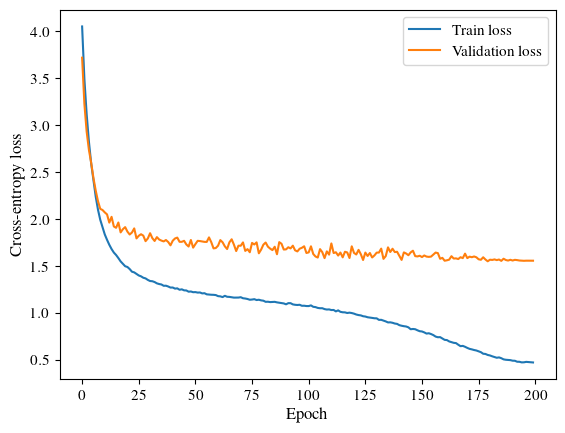

In [4]:
# Hyperparameter config. Can also be retrieved using OmegaConf.load("config/cifar100__ivon.yaml")
config = DictConfig({
    "lr": 0.2,
    "batch": 50,
    "epochs": 200,
    "warmup_epochs": 5,
    "optim": {
      "n_samples": 1,
      "lambda_": len(train_set),
      "h0": 0.5,
      "beta1": 0.9,
      "beta2": 0.99999,
      "weight_decay": 0.0002,
    },
    "n_classes": 100
})

# Setup model and optimizer
model = init_model("resnet20", n_classes=config.n_classes)
model.to(device)
optimizer = init_optimizer(model, "ivon", config=config)

# Do the training loop; checkpoints are regularly saved to 'checkpoints/cifar100'
model.train()
train_losses, val_losses = train(
    dataset_name="cifar100",
    model_name="resnet20",
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config
)

# Plot the loss curve
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

## AdamW

Epoch 0; train_loss=3.945; val_loss=3.645
Saving checkpoint to 'checkpoints/cifar100/resnet20__adamw__1.pt' ...
Epoch 1; train_loss=3.433; val_loss=3.217
Saving checkpoint to 'checkpoints/cifar100/resnet20__adamw__2.pt' ...
Epoch 2; train_loss=3.058; val_loss=2.917
Epoch 3; train_loss=2.787; val_loss=2.69
Epoch 4; train_loss=2.561; val_loss=2.567
Saving checkpoint to 'checkpoints/cifar100/resnet20__adamw__5.pt' ...
Epoch 5; train_loss=2.391; val_loss=2.419
Epoch 6; train_loss=2.205; val_loss=2.228
Epoch 7; train_loss=2.075; val_loss=2.206
Epoch 8; train_loss=1.964; val_loss=2.167
Epoch 9; train_loss=1.872; val_loss=2.079
Saving checkpoint to 'checkpoints/cifar100/resnet20__adamw__10.pt' ...
Epoch 10; train_loss=1.791; val_loss=2.045
Epoch 11; train_loss=1.728; val_loss=1.957
Epoch 12; train_loss=1.668; val_loss=2.01
Epoch 13; train_loss=1.616; val_loss=1.906
Epoch 14; train_loss=1.557; val_loss=1.877
Epoch 15; train_loss=1.516; val_loss=1.841
Epoch 16; train_loss=1.475; val_loss=1.777


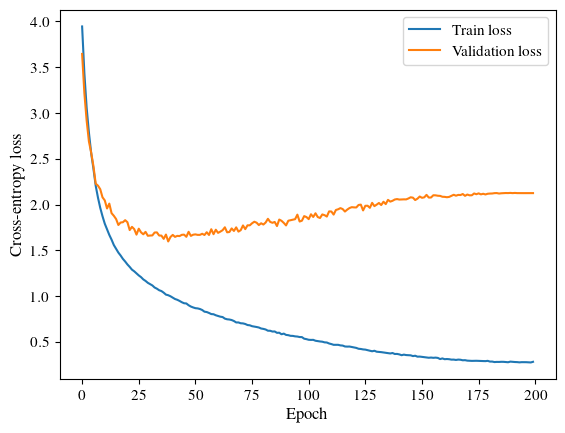

In [6]:
config = DictConfig({
    "lr": 0.002,
    "batch": 50,
    "epochs": 200,
    "warmup_epochs": 5,
    "optim": {
      "beta1": 0.9,
      "beta2": 0.999,
      "weight_decay": 0.0002,
    },
    "n_classes": 100
})

# Setup model and optimizer
model = init_model("resnet20", n_classes=config.n_classes)
model.to(device)
optimizer = init_optimizer(model, "adamw", config=config)

# Do the training loop; checkpoints are regularly saved to 'checkpoints/cifar100'
model.train()
train_losses, val_losses = train(
    dataset_name="cifar100",
    model_name="resnet20",
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config
)

# Plot the loss curve
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

## SGD

Epoch 0; train_loss=3.969; val_loss=3.639
Saving checkpoint to 'checkpoints/cifar100/resnet20__sgd__1.pt' ...
Epoch 1; train_loss=3.468; val_loss=3.213
Saving checkpoint to 'checkpoints/cifar100/resnet20__sgd__2.pt' ...
Epoch 2; train_loss=3.046; val_loss=2.912
Epoch 3; train_loss=2.715; val_loss=2.773
Epoch 4; train_loss=2.502; val_loss=2.424
Saving checkpoint to 'checkpoints/cifar100/resnet20__sgd__5.pt' ...
Epoch 5; train_loss=2.359; val_loss=2.491
Epoch 6; train_loss=2.211; val_loss=2.293
Epoch 7; train_loss=2.106; val_loss=2.264
Epoch 8; train_loss=2.032; val_loss=2.226
Epoch 9; train_loss=1.961; val_loss=2.111
Saving checkpoint to 'checkpoints/cifar100/resnet20__sgd__10.pt' ...
Epoch 10; train_loss=1.93; val_loss=2.156
Epoch 11; train_loss=1.882; val_loss=2.093
Epoch 12; train_loss=1.846; val_loss=2.054
Epoch 13; train_loss=1.819; val_loss=2.026
Epoch 14; train_loss=1.793; val_loss=2.006
Epoch 15; train_loss=1.771; val_loss=1.944
Epoch 16; train_loss=1.759; val_loss=2.028
Epoch 1

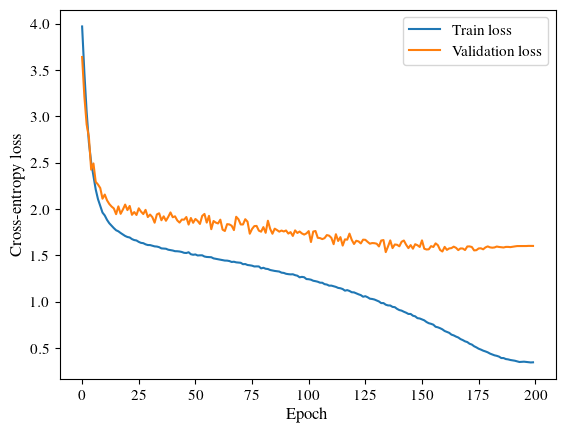

In [4]:
config = DictConfig({
    "lr": 0.1,
    "batch": 50,
    "epochs": 200,
    "warmup_epochs": 5,
    "optim": {
      "beta1": 0.9,
      "weight_decay": 0.0002,
    },
    "n_classes": 100
})

# Setup model and optimizer
model = init_model("resnet20", n_classes=config.n_classes)
model.to(device)
optimizer = init_optimizer(model, "sgd", config=config)

# Do the training loop; checkpoints are regularly saved to 'checkpoints/cifar100'
model.train()
train_losses, val_losses = train(
    dataset_name="cifar100",
    model_name="resnet20",
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config
)

# Plot the loss curve
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

# CIFAR-10
Now, we move on to the main checkpoints on CIFAR-10

In [5]:
# Load the datasets
train_set, val_set, _test_set = load_dataset("cifar10", train_ratio=0.9, seed=42)

train_loader = DataLoader(train_set, batch_size=50, shuffle=True)
val_loader = DataLoader(val_set, batch_size=50, shuffle=False)

## IVON

Epoch 0; train_loss=1.588; val_loss=1.425
Saving checkpoint to 'checkpoints/cifar10/resnet20__ivon__1.pt' ...
Epoch 1; train_loss=1.197; val_loss=1.1
Saving checkpoint to 'checkpoints/cifar10/resnet20__ivon__2.pt' ...
Epoch 2; train_loss=0.9885; val_loss=0.9536
Epoch 3; train_loss=0.8625; val_loss=0.8233
Epoch 4; train_loss=0.7645; val_loss=0.7971
Saving checkpoint to 'checkpoints/cifar10/resnet20__ivon__5.pt' ...
Epoch 5; train_loss=0.7043; val_loss=0.7385
Epoch 6; train_loss=0.6402; val_loss=0.6616
Epoch 7; train_loss=0.5883; val_loss=0.6217
Epoch 8; train_loss=0.5584; val_loss=0.6156
Epoch 9; train_loss=0.5268; val_loss=0.616
Saving checkpoint to 'checkpoints/cifar10/resnet20__ivon__10.pt' ...
Epoch 10; train_loss=0.5021; val_loss=0.572
Epoch 11; train_loss=0.4894; val_loss=0.551
Epoch 12; train_loss=0.4733; val_loss=0.5435
Epoch 13; train_loss=0.4543; val_loss=0.5545
Epoch 14; train_loss=0.4477; val_loss=0.5689
Epoch 15; train_loss=0.4302; val_loss=0.5509
Epoch 16; train_loss=0.425

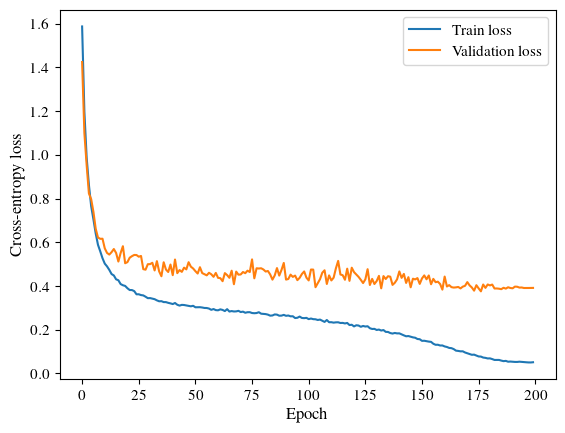

In [7]:
# Hyperparameter config. Can also be retrieved using OmegaConf.load("config/cifar10__ivon.yaml")
config = DictConfig({
    "lr": 0.2,
    "batch": 50,
    "epochs": 200,
    "warmup_epochs": 5,
    "optim": {
      "n_samples": 1,
      "lambda_": len(train_set),
      "h0": 0.5,
      "beta1": 0.9,
      "beta2": 0.99999,
      "weight_decay": 0.0002,
    },
    "n_classes": 10
})

model = init_model("resnet20", n_classes=config.n_classes)
model.to(device)
optimizer = init_optimizer(model, "ivon", config=config)

model.train()
train_losses, val_losses = train(
    dataset_name="cifar10",
    model_name="resnet20",
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config
)

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

## AdamW

Epoch 0; train_loss=1.47; val_loss=1.186
Saving checkpoint to 'checkpoints/cifar10/resnet20__adamw__1.pt' ...
Epoch 1; train_loss=1.117; val_loss=1.009
Saving checkpoint to 'checkpoints/cifar10/resnet20__adamw__2.pt' ...
Epoch 2; train_loss=0.9455; val_loss=0.9057
Epoch 3; train_loss=0.8319; val_loss=0.7811
Epoch 4; train_loss=0.7579; val_loss=0.7647
Saving checkpoint to 'checkpoints/cifar10/resnet20__adamw__5.pt' ...
Epoch 5; train_loss=0.6963; val_loss=0.6618
Epoch 6; train_loss=0.6346; val_loss=0.6493
Epoch 7; train_loss=0.5906; val_loss=0.6218
Epoch 8; train_loss=0.5537; val_loss=0.5996
Epoch 9; train_loss=0.5239; val_loss=0.6037
Saving checkpoint to 'checkpoints/cifar10/resnet20__adamw__10.pt' ...
Epoch 10; train_loss=0.4997; val_loss=0.5637
Epoch 11; train_loss=0.472; val_loss=0.538
Epoch 12; train_loss=0.4513; val_loss=0.5341
Epoch 13; train_loss=0.4296; val_loss=0.5072
Epoch 14; train_loss=0.4145; val_loss=0.5116
Epoch 15; train_loss=0.3947; val_loss=0.5088
Epoch 16; train_loss

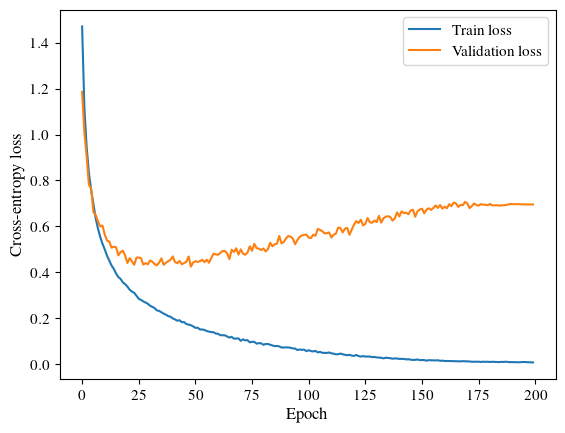

In [8]:
config = DictConfig({
    "lr": 0.002,
    "batch": 50,
    "epochs": 200,
    "warmup_epochs": 5,
    "optim": {
      "beta1": 0.9,
      "beta2": 0.999,
      "weight_decay": 0.0002,
    },
    "n_classes": 10
})

# Setup model and optimizer
model = init_model("resnet20", n_classes=config.n_classes)
model.to(device)
optimizer = init_optimizer(model, "adamw", config=config)

# Do the training loop; checkpoints are regularly saved to 'checkpoints/cifar100'
model.train()
train_losses, val_losses = train(
    dataset_name="cifar10",
    model_name="resnet20",
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config
)

# Plot the loss curve
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

## SGD

Epoch 0; train_loss=1.584; val_loss=1.225
Saving checkpoint to 'checkpoints/cifar10/resnet20__sgd__1.pt' ...
Epoch 1; train_loss=1.137; val_loss=1.01
Saving checkpoint to 'checkpoints/cifar10/resnet20__sgd__2.pt' ...
Epoch 2; train_loss=0.9232; val_loss=0.8455
Epoch 3; train_loss=0.8161; val_loss=0.7663
Epoch 4; train_loss=0.7533; val_loss=0.6942
Saving checkpoint to 'checkpoints/cifar10/resnet20__sgd__5.pt' ...
Epoch 5; train_loss=0.7236; val_loss=0.6918
Epoch 6; train_loss=0.6719; val_loss=0.6617
Epoch 7; train_loss=0.6454; val_loss=0.6351
Epoch 8; train_loss=0.6176; val_loss=0.6887
Epoch 9; train_loss=0.5907; val_loss=0.6509
Saving checkpoint to 'checkpoints/cifar10/resnet20__sgd__10.pt' ...
Epoch 10; train_loss=0.584; val_loss=0.6264
Epoch 11; train_loss=0.5684; val_loss=0.6155
Epoch 12; train_loss=0.5559; val_loss=0.63
Epoch 13; train_loss=0.5542; val_loss=0.5991
Epoch 14; train_loss=0.55; val_loss=0.6079
Epoch 15; train_loss=0.5413; val_loss=0.5912
Epoch 16; train_loss=0.5275; va

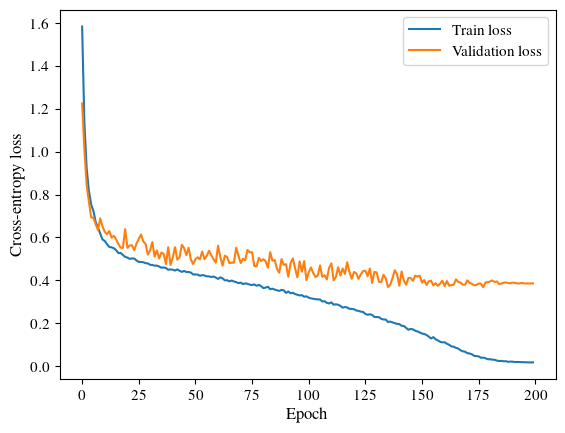

In [9]:
config = DictConfig({
    "lr": 0.1,
    "batch": 50,
    "epochs": 200,
    "warmup_epochs": 5,
    "optim": {
      "beta1": 0.9,
      "weight_decay": 0.0002,
    },
    "n_classes": 10
})

# Setup model and optimizer
model = init_model("resnet20", n_classes=config.n_classes)
model.to(device)
optimizer = init_optimizer(model, "sgd", config=config)

# Do the training loop; checkpoints are regularly saved to 'checkpoints/cifar100'
model.train()
train_losses, val_losses = train(
    dataset_name="cifar10",
    model_name="resnet20",
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config
)

# Plot the loss curve
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

## Varying MC samples during IVON training
One of the experiments we later conduct is to compare the effect of the number of MC samples used during training of IVON.
Here we train some models with varying numbers of samples. The code only shows one of the runs, but the remaining checkpoints were trained in the same way.

Config:

lr: 0.2
batch: 50
epochs: 200
warmup_epochs: 5
optim:
  n_samples: 2
  lambda_: 45000
  h0: 0.5
  beta1: 0.9
  beta2: 0.99999
  weight_decay: 0.0002
n_classes: 10


Epoch 0; train_loss=1.554
Saving checkpoint to 'checkpoints/cifar10/resnet20__ivon__1__samples2.pt' ...
Epoch 1; train_loss=1.148
Saving checkpoint to 'checkpoints/cifar10/resnet20__ivon__2__samples2.pt' ...
Epoch 2; train_loss=0.9612
Epoch 3; train_loss=0.8437
Epoch 4; train_loss=0.7695
Saving checkpoint to 'checkpoints/cifar10/resnet20__ivon__5__samples2.pt' ...
Epoch 5; train_loss=0.7048
Epoch 6; train_loss=0.6371
Epoch 7; train_loss=0.5897
Epoch 8; train_loss=0.5554
Epoch 9; train_loss=0.5253
Saving checkpoint to 'checkpoints/cifar10/resnet20__ivon__10__samples2.pt' ...
Epoch 10; train_loss=0.505
Epoch 11; train_loss=0.4847
Epoch 12; train_loss=0.4622
Epoch 13; train_loss=0.4569
Epoch 14; train_loss=0.4356
Epoch 15; train_loss=0.4253
Epoch 16; train_loss=0.4152
Epoch 17; train_loss=0.4073
Epoch 18; train_loss=0

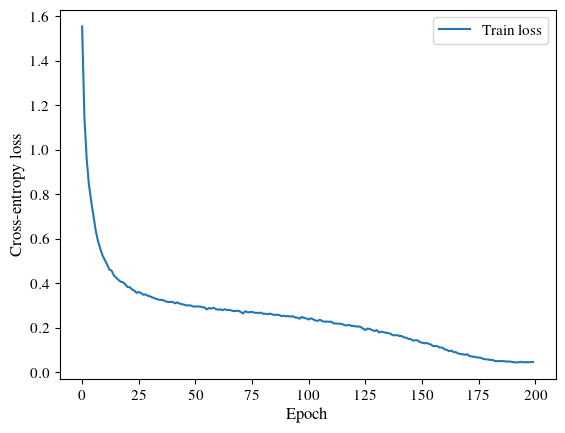

In [19]:
N_SAMPLES = 2

config = OmegaConf.load("configs/cifar10__ivon.yaml")
config.optim.update({"n_samples": N_SAMPLES})  # Modify the default n_samples config
print("Config:", OmegaConf.to_yaml(config), sep="\n\n", end="\n\n")

model = init_model("resnet20", n_classes=config.n_classes)
model.to(device)
optimizer = init_optimizer(model, "ivon", config=config)

model.train()
train_losses, _ = train(
    dataset_name="cifar10",
    model_name="resnet20",
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=None,  # Skip validation to speed up training
    config=config
)

plt.plot(train_losses, label="Train loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

